<a href="https://colab.research.google.com/github/EmanuelMatiasCinel/Proyecto-Final-Data-Science/blob/main/Grupo_16_Proyecto_Data_Science_estructura_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grupo 16 - Proyecto Data Science
## Semáforo Financiero: clasificación de empresas según sus ratios contables-financieros


**Objetivo:** construir un semáforo (Aceptable / Medio / Regular) que clasifique a cada empresa comparando sus ratios financiero-contables contra la media de su propio sector, año a año.

**Fuente de datos:** "200+ Financial Indicators of US stocks (2014-2018)", Kaggle, usuario Nicolas Carbone.
URL: https://www.kaggle.com/datasets/cnic92/200-financial-indicators-of-us-stocks-20142018

**Importante:** el semáforo lo construimos nosotros a partir de los mismos ratios que después vamos a usar para describir a cada empresa. No es lo mismo que la columna `Class` que ya viene en el dataset (esa indica si el precio de la acción subió o bajó al año siguiente, y no la vamos a usar como target).

## 0. Preparación del entorno

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

## 1. Carga y unificación de los 5 años

Se subió los 5 archivos (`2014_Financial_Data.csv` ... `2018_Financial_Data.csv`) con el panel de archivos de la izquierda en Colab (el ícono de la carpeta → "Subir").

Se detectó que la primer columna donde se nombra el ticker de la empresa, aparece en blanco, es asi que Renombramos esa columna y agregamos `Year`. El resto de los nombres los dejamos tal cual vienen del CSV original (con mayúsculas y espacios) porque todavía los necesitamos así para la selección de columnas del paso 3.

In [ ]:
anios = [2014, 2015, 2016, 2017, 2018]
tablas = []

for anio in anios:
    tabla = pd.read_csv(f"{anio}_Financial_Data.csv")
    tabla = tabla.rename(columns={"Unnamed: 0": "Ticker"})
    # la columna de variación de precio se llama '<anio+1> PRICE VAR [%]': la generalizamos
    columna_precio = [c for c in tabla.columns if "PRICE VAR" in c][0]
    tabla = tabla.rename(columns={columna_precio: "Price Var Next Year"})
    tabla["Year"] = anio
    tablas.append(tabla)

df_completo = pd.concat(tablas, ignore_index=True)
print("Filas:", df_completo.shape[0], "| Columnas:", df_completo.shape[1])
df_completo.head()

Filas: 22077 | Columnas: 226


,Ticker,Revenue,Revenue Growth,Cost of Revenue,Gross Profit,R&D Expenses,SG&A Expense,Operating Expenses,Operating Income,Interest Expense,Earnings before Tax,Income Tax Expense,Net Income - Non-Controlling int,Net Income - Discontinued ops,Net Income,Preferred Dividends,Net Income Com,EPS,EPS Diluted,Weighted Average Shs Out,Weighted Average Shs Out (Dil),Dividend per Share,Gross Margin,EBITDA Margin,EBIT Margin,...,5Y Revenue Growth (per Share),3Y Revenue Growth (per Share),10Y Operating CF Growth (per Share),5Y Operating CF Growth (per Share),3Y Operating CF Growth (per Share),10Y Net Income Growth (per Share),5Y Net Income Growth (per Share),3Y Net Income Growth (per Share),10Y Shareholders Equity Growth (per Share),5Y Shareholders Equity Growth (per Share),3Y Shareholders Equity Growth (per Share),10Y Dividend per Share Growth (per Share),5Y Dividend per Share Growth (per Share),3Y Dividend per Share Growth (per Share),Receivables growth,Inventory Growth,Asset Growth,Book Value per Share Growth,Debt Growth,R&D Expense Growth,SG&A Expenses Growth,Sector,Price Var Next Year,Class,Year
0,PG,7.440100e+10,-0.0713,3.903000e+10,3.537100e+10,0.000000e+00,2.146100e+10,2.146100e+10,1.391000e+10,7.090000e+08,1.449400e+10,2.851000e+09,1.420000e+08,-1.127000e+09,1.164300e+10,0.0,1.164300e+10,4.1900,4.010,2.705960e+09,2.705960e+09,2.448,0.4754,0.2470,0.2043,...,0.0088,-0.0182,0.0355,0.0015,0.0260,0.0603,-0.0137,0.0060,0.1442,0.0353,0.0201,0.1013,0.0834,0.0751,-0.0187,-0.0217,0.0359,0.0316,0.1228,0.0000,-0.1746,Consumer Defensive,-9.323276,0,2014
1,VIPS,3.734148e+09,1.1737,2.805625e+09,9.285226e+08,1.083303e+08,3.441414e+08,7.939267e+08,1.345959e+08,1.214869e+07,1.753823e+08,3.955957e+07,-1.431918e+07,0.000000e+00,1.358227e+08,0.0,1.358227e+08,0.2396,0.226,NaN,1.829362e+07,0.000,0.2487,0.0107,0.0502,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6484,1.7313,Consumer Defensive,-25.512193,0,2014
2,KR,9.837500e+10,0.0182,7.813800e+10,2.023700e+10,0.000000e+00,1.519600e+10,1.751200e+10,2.725000e+09,4.430000e+08,2.270000e+09,7.510000e+08,1.200000e+07,0.000000e+00,1.519000e+09,0.0,1.519000e+09,1.4700,1.450,1.033053e+09,1.028000e+09,0.307,0.2057,0.0450,0.0276,...,0.1038,0.1399,0.0889,0.0937,0.0946,0.2272,0.0906,0.1892,0.0676,0.0558,0.0789,0.0000,0.1215,0.1633,0.0618,0.0981,0.1886,0.3268,0.2738,0.0000,0.0234,Consumer Defensive,33.118297,1,2014
3,RAD,2.552641e+10,0.0053,1.820268e+10,7.323734e+09,0.000000e+00,6.561162e+09,6.586482e+09,7.372520e+08,4.245910e+08,2.502180e+08,8.040000e+05,0.000000e+00,0.000000e+00,2.494140e+08,33998000.0,2.154160e+08,4.6000,4.600,4.832628e+07,4.832628e+07,0.000,0.2869,0.0420,0.0264,...,-0.0290,-0.0230,0.0513,0.1164,0.1777,0.0480,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0211,-0.0510,-0.0189,0.1963,-0.0458,0.0000,-0.0060,Consumer Defensive,2.752291,1,2014
4,GIS,1.790960e+10,0.0076,1.153980e+10,6.369800e+09,0.000000e+00,3.474300e+09,3.412400e+09,2.957400e+09,3.024000e+08,2.707700e+09,8.833000e+08,3.690000e+07,0.000000e+00,1.824400e+09,0.0,1.824400e+09,2.9000,2.830,6.144922e+08,6.144922e+08,1.550,0.3557,0.2010,0.1681,...,0.0567,0.0773,0.0782,0.0828,0.1991,0.0776,0.0841,0.0177,0.0427,0.0623,0.0217,0.1092,0.1250,0.1144,0.0257,0.0090,0.0215,0.0274,0.1025,0.0000,-0.0220,Consumer Defensive,12.897715,1,2014


## 2. Diagnóstico inicial (sobre el dataset completo)

Las tres preguntas de siempre: cuántas filas y columnas, de qué tipo es cada variable, y qué tan completa está. Lo hacemos sobre las 225 columnas originales, antes de recortar, para tener una foto completa del dataset crudo.

In [ ]:
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22077 entries, 0 to 22076
Columns: 226 entries, Ticker to Year
dtypes: float64(222), int64(2), object(2)
memory usage: 38.1+ MB


In [ ]:
print("Filas duplicadas:", df_completo.duplicated().sum())
print("Empresas (tickers) distintas:", df_completo["Ticker"].nunique())
print("Sectores:", df_completo["Sector"].nunique())
df_completo["Sector"].value_counts()

Filas duplicadas: 0
Empresas (tickers) distintas: 4980
Sectores: 11


,count
Sector,
Financial Services,4720
Healthcare,3305
Technology,3126
Industrials,2768
Consumer Cyclical,2471
Basic Materials,1344
Real Estate,1241
Energy,1217
Consumer Defensive,922


## 3. Selección de columnas

Del dataset completo (225 columnas) nos quedamos con las que definimos por criterio financiero: valuación, rentabilidad, liquidez, endeudamiento, crecimiento y dividendos, más `Ticker`, `Year` y `Sector` para identificar cada fila, y `Class` como columna de referencia (no la vamos a usar para construir el semáforo, porque el objetivo es armar nuestra propia clasificación, no repetir la que ya viene calculada en el dataset).

**Atención:** `'Free Cash Flow Margin'` no existe con ese nombre exacto en el CSV original — la columna real se llama `'Free Cash Flow margin'` (con minúscula). Ya está corregido acá abajo, pero es un buen ejemplo de por qué conviene chequear `col in df_completo.columns` antes de dar por hecho que una columna quedó como querían.

**Ojo también con los casi-duplicados.** El dataset trae el mismo ratio dos veces con nombres distintos en varios casos (por ejemplo `ROE` y `returnOnEquity` miden lo mismo); acá elegimos una sola versión de cada uno. `Dividend Yield` es un caso aparte: las dos versiones que trae el dataset NO coinciden entre sí, así que conviene revisar cuál de las dos tiene más sentido antes de decidir (armen una celda que las compare, por ejemplo con `.describe()` o graficando ambas).

##De la base de datos completa se utilizaran solamente las siguientes columnas:
**Valuación — "¿está cara o barata la acción?"**

•	**P/E (Price/Earnings):** cuántos años de ganancia actual hacen falta para "pagar" el precio de la acción. Bajo = parece barata (o el mercado no confía en su futuro); alto = cara (o el mercado espera que crezca mucho).

•	**P/B (Price/Book):** precio de la acción vs. el valor contable de sus activos. Sirve para ver si el mercado paga mucho más de lo que la empresa "vale en el papel".

**Rentabilidad — "¿gana plata de forma eficiente?"**

•	**ROE (Return on Equity):** por cada $1 que pusieron los accionistas, cuánta ganancia generó la empresa. Es el ratio más citado en análisis fundamental.

•	**ROA (Return on Assets):** El ROA mide cuánta ganancia genera una empresa por cada peso (o dólar) que tiene invertido en sus activos totales

•	**ROIC (Return of Invested Capital):** El ROIC mide cuánta ganancia operativa genera una empresa por cada peso (o dólar) de capital que realmente se usó para financiar el negocio

•	**Net Profit Margin:** de cada $100 que factura, cuántos terminan siendo ganancia neta (después de todos los gastos e impuestos).
Liquidez — "¿puede pagar sus deudas de corto plazo?"

•	**Current Ratio:** activos que puede convertir en efectivo rápido, divididos por lo que debe pagar pronto. Menor a 1 es señal de alerta (podría no cubrir sus obligaciones inmediatas).

•	**Free Cash Flow Margin:** % de las ventas que se convierte en caja libre (comparable entre empresas)

**Endeudamiento — "¿cuánta deuda tiene en relación a lo suyo?"**

•	**Debt to Equity:** deuda total / patrimonio de los accionistas. Alto = la empresa se financia mucho con deuda (más riesgo si suben las tasas o caen las ventas).

• **Interest Coverage:** Mide cuántas veces la ganancia operativa cubre los intereses de la deuda.

**Crecimiento — "¿está creciendo o estancada?"**

•	**Revenue Growth (YoY):** cuánto crecieron las ventas respecto al año anterior. Un solo número, no una serie — está permitido.

•	**EPS Growth (YoY):** cuánto creció la ganancia por acción respecto al año anterior.

**Dividendos y contexto**

•	**Dividend Yield:** qué % del precio de la acción se devuelve como dividendo anual.

•	**Market Cap:** tamaño de la empresa (grande/mediana/chica) — importante porque empresas grandes y chicas se comportan distinto.

•	**Sector:** la categórica clave — sin esto no se puede comparar "contra la industria" ni hacer clustering con sentido.

In [ ]:
##De la base de datos completa se utilizaran solamente las siguientes columnas:
columnas_deseadas = ['Ticker', 'Year', 'PE ratio', 'PB ratio', 'ROE', 'returnOnAssets', 'ROIC',
                      'Net Profit Margin', 'Free Cash Flow margin', 'Current ratio', 'Debt to Equity',
                      'Interest Coverage', 'Revenue Growth', 'EPS Growth',
                      'Dividend Yield', 'Market Cap', 'Sector', 'Class']

for col in columnas_deseadas:
    print(col, '->', col in df_completo.columns)

Ticker -> True
Year -> True
PE ratio -> True
PB ratio -> True
ROE -> True
returnOnAssets -> True
ROIC -> True
Net Profit Margin -> True
Free Cash Flow margin -> True
Current ratio -> True
Debt to Equity -> True
Interest Coverage -> True
Revenue Growth -> True
EPS Growth -> True
Dividend Yield -> True
Market Cap -> True
Sector -> True
Class -> True


In [ ]:
# Dropeamos todo lo que no está en columnas_deseadas y nos quedamos con df_completo recortado
df = df_completo[columnas_deseadas].copy()
print("Filas:", df.shape[0], "| Columnas:", df.shape[1])
df.head()

Filas: 22077 | Columnas: 18


,Ticker,Year,PE ratio,PB ratio,ROE,returnOnAssets,ROIC,Net Profit Margin,Free Cash Flow margin,Current ratio,Debt to Equity,Interest Coverage,Revenue Growth,EPS Growth,Dividend Yield,Market Cap,Sector,Class
0,PG,2014,18.7566,3.0391,0.1664,0.5765,0.0753,0.1565,0.1359,0.9370,0.5061,21.4429,-0.0713,0.0371,0.0311,2.126614e+11,Consumer Defensive,0
1,VIPS,2014,81.5526,NaN,0.3294,0.0403,0.0000,0.0364,0.0704,0.2102,1.5093,15.4363,1.1737,1.4625,0.0000,6.253200e+09,Consumer Defensive,0
2,KR,2014,12.0340,3.3579,0.2821,0.1011,0.0859,0.0154,0.0126,0.8250,2.1007,6.1242,0.0182,0.0576,0.0174,1.827470e+10,Consumer Defensive,1
3,RAD,2014,28.6087,0.0000,-0.1180,0.0668,0.1062,0.0098,0.0144,1.7090,-2.7237,1.5893,0.0053,0.9167,0.0000,6.359738e+09,Consumer Defensive,1
4,GIS,2014,18.7034,5.1004,0.2792,0.6265,0.1041,0.1019,0.1052,0.8100,1.3445,9.9540,0.0076,0.0140,0.0286,3.333006e+10,Consumer Defensive,1


### Normalizamos los nombres de las columnas que sobrevivieron

Recién ahora, con el dataset ya recortado, aplicamos la normalización de nombres (todo en minúscula, sin espacios, con guión bajo como separador) para trabajar más cómodos en el resto de la notebook.

In [ ]:
def normalizar_nombre(columna):
    """Pasa un nombre de columna a minúsculas y reemplaza separadores por guión bajo."""
    nombre = columna.strip().lower()
    nombre = re.sub(r"[ /&\-]+", "_", nombre)
    return nombre

df.columns = [normalizar_nombre(c) for c in df.columns]
df.columns.tolist()

['ticker',
 'year',
 'pe_ratio',
 'pb_ratio',
 'roe',
 'returnonassets',
 'roic',
 'net_profit_margin',
 'free_cash_flow_margin',
 'current_ratio',
 'debt_to_equity',
 'interest_coverage',
 'revenue_growth',
 'eps_growth',
 'dividend_yield',
 'market_cap',
 'sector',
 'class']

## 4. Valores faltantes

Varias de estas columnas rondan el 25% de faltantes. Antes de imputar, miren si el faltante se concentra en algún sector o año particular (como hicimos con `population` por país en la clase). Después, imputen **por sector**, que es más preciso que usar la mediana global — dos empresas de sectores muy distintos no son comparables.

In [ ]:
columnas_ratio = ["pe_ratio", "pb_ratio", "roe", "returnonassets", "roic",
                  "net_profit_margin", "free_cash_flow_margin", "current_ratio", "debt_to_equity",
                  "interest_coverage", "revenue_growth", "eps_growth",
                  "dividend_yield", "market_cap"]

faltantes = pd.DataFrame({
    "cantidad": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(2),
})
faltantes[faltantes["cantidad"] > 0].sort_values("porcentaje", ascending=False)

,cantidad,porcentaje
returnonassets,6535,29.60
current_ratio,6516,29.51
roic,6509,29.48
pb_ratio,4977,22.54
market_cap,3071,13.91
roe,2340,10.60
debt_to_equity,2314,10.48
free_cash_flow_margin,2291,10.38
pe_ratio,2248,10.18
dividend_yield,2246,10.17


In [ ]:
# TODO: graficar el porcentaje de faltantes por columna (barplot, como en la clase)


In [ ]:
# TODO: imputar cada columna de columnas_ratio con la mediana de su propio sector,
# y recién si queda algún faltante, usar la mediana global.
# Pista: df.groupby("sector")[columna].transform(lambda serie: serie.fillna(serie.median()))


## 5. Outliers

Estos ratios pueden dispararse a valores absurdos cuando el denominador (patrimonio, activos) es casi cero o negativo. Por ejemplo `pb_ratio` puede llegar a millones. En vez de usar el criterio de RIC de la clase para eliminar filas, acá conviene **winsorizar**: recortar cada columna a un percentil bajo y uno alto, para no perder la fila completa por un solo valor extremo.

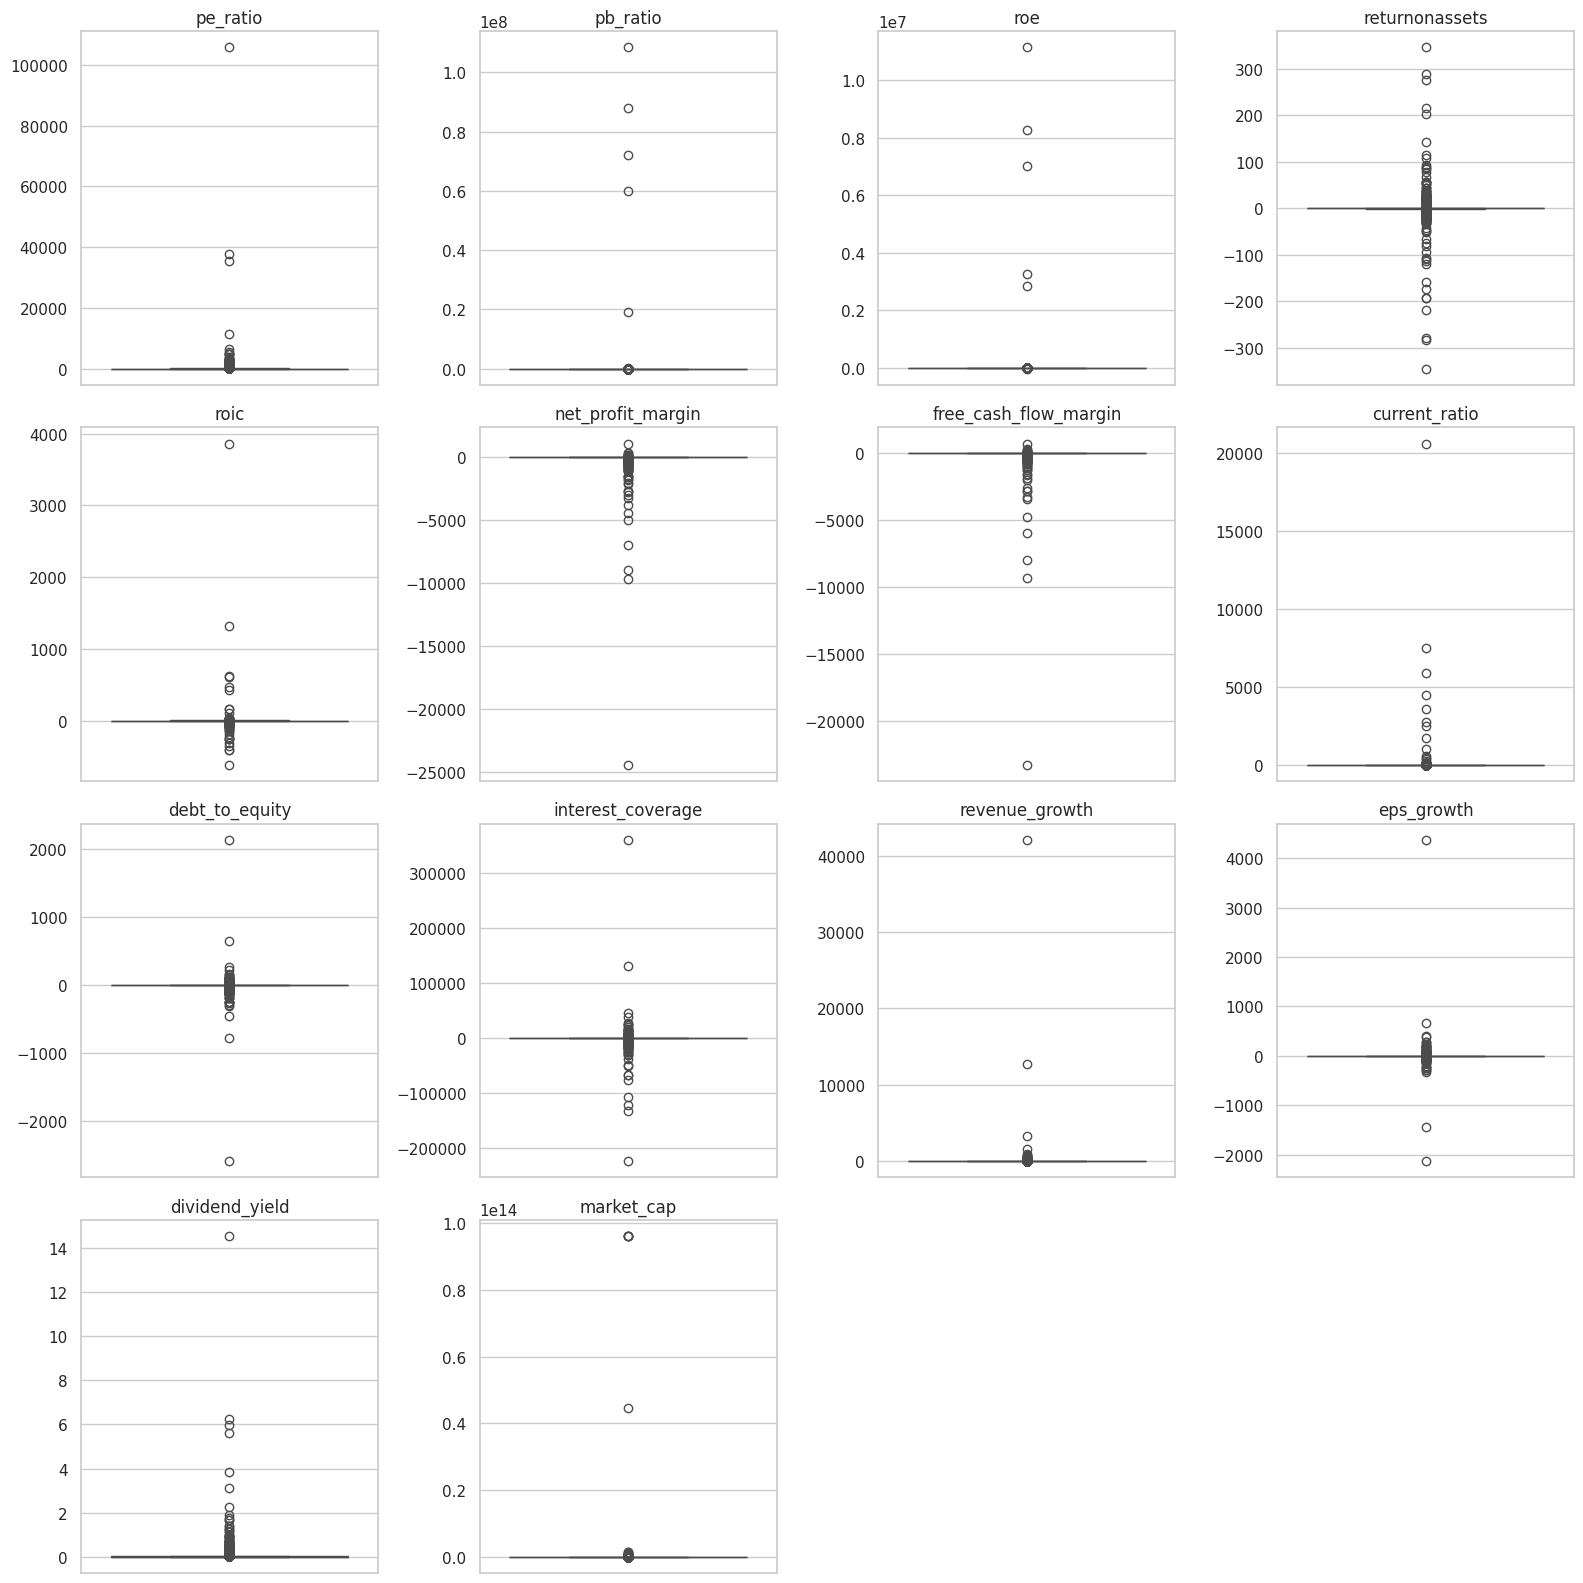

In [ ]:
ncols = 4
nrows = -(-len(columnas_ratio) // ncols)  # redondeo hacia arriba
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))

for eje, columna in zip(axes.flat, columnas_ratio):
    sns.boxplot(y=df[columna], ax=eje, color="#4C72B0")
    eje.set_title(columna)
    eje.set_ylabel("")

for eje in axes.flat[len(columnas_ratio):]:
    eje.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def winsorizar(serie, percentil_bajo=0.01, percentil_alto=0.99):
    """Recorta una serie a sus percentiles bajo y alto."""
    limite_bajo = serie.quantile(percentil_bajo)
    limite_alto = serie.quantile(percentil_alto)
    return serie.clip(limite_bajo, limite_alto)

# TODO: aplicar winsorizar a cada columna de columnas_ratio (guardar en el mismo df o en columnas nuevas)
# TODO: volver a graficar los boxplots después de winsorizar y comparar contra los de arriba


## 6. Comparar cada empresa contra su sector (z-score por grupo)

Acá está el corazón del semáforo. No queremos saber si un ratio es alto o bajo en términos absolutos, sino **comparado con las demás empresas del mismo sector y año**. Para eso calculamos un z-score dentro de cada grupo `(sector, year)`.

In [ ]:
def zscore_por_grupo(serie):
    return (serie - serie.mean()) / serie.std()

for columna in columnas_ratio:
    df[f"z_{columna}"] = df.groupby(["sector", "year"])[columna].transform(zscore_por_grupo)

df[[f"z_{c}" for c in columnas_ratio]].describe().T

,count,mean,std,min,25%,50%,75%,max
z_pe_ratio,19829.0,6.091697e-18,0.998637,-0.841682,-0.227948,-0.136201,-0.039312,25.772516
z_pb_ratio,17100.0,-8.725963e-18,0.998420,-2.369282,-0.222581,-0.093596,-0.040324,24.779056
z_roe,19737.0,3.240049e-18,0.998631,-26.188875,-0.048494,-0.032177,0.049795,25.865063
z_returnonassets,15542.0,-8.572048e-19,0.998261,-24.512260,-0.060719,0.007965,0.071328,23.002537
z_roic,15568.0,-2.282062e-19,0.998264,-22.961975,-0.040693,0.081339,0.159262,15.414070
z_net_profit_margin,20355.0,3.490753e-19,0.998673,-26.257257,0.045363,0.071168,0.112848,25.963821
z_free_cash_flow_margin,19786.0,-7.182278e-19,0.998634,-25.980055,0.040326,0.082469,0.122539,25.545292
z_current_ratio,15561.0,5.479412e-18,0.998263,-2.424687,-0.457157,-0.193735,0.104190,18.558050
z_debt_to_equity,19763.0,-2.606606e-18,0.998633,-25.149190,-0.087898,-0.009624,0.059493,24.871673
z_interest_coverage,19920.0,-3.566982e-19,0.998644,-25.781790,-0.076164,-0.026902,0.061487,24.957893


## 7. Score compuesto y semáforo

No todos los ratios son "más alto = mejor": para `debt_to_equity` un valor más bajo es preferible, así que a su z-score hay que invertirle el signo antes de sumarlo. `pe_ratio` y `pb_ratio` no tienen una dirección clara (ni muy alto ni muy bajo es automáticamente bueno o malo), así que los dejamos afuera del score y los usamos solo como columnas informativas.

In [ ]:
# Ratios donde un valor más alto es mejor
columnas_positivas = ["roe", "returnonassets", "roic", "net_profit_margin", "free_cash_flow_margin",
                      "current_ratio", "interest_coverage", "revenue_growth", "eps_growth"]

# Ratios donde un valor más bajo es mejor
columnas_negativas = ["debt_to_equity"]

# TODO: armar la lista de columnas z (con signo ya corregido) que van a entrar al score.
# Pista: para las columnas_negativas hay que multiplicar el z-score por -1 antes de promediar.

# TODO: calcular df["score_financiero"] como el promedio de esas columnas con signo corregido.


In [ ]:
# TODO: convertir score_financiero en el semáforo con pd.qcut (3 grupos) o con cortes manuales
# que definan ustedes (por ejemplo score > 0.5 -> Aceptable, entre -0.5 y 0.5 -> Medio, < -0.5 -> Regular).
# Guardar el resultado en df["semaforo"].


## 8. Exploración del semáforo

Con el semáforo ya armado, viene la parte de EDA propiamente dicha: describir cómo se distribuye y si tiene sentido con lo que sabemos del negocio.

In [ ]:
# TODO: distribución del semáforo en general (value_counts + gráfico de barras)


In [ ]:
# TODO: distribución del semáforo por sector (¿algún sector tiene más empresas "Regular" que otros?)


In [ ]:
# TODO: boxplot de 2 o 3 ratios clave (por ejemplo roe, debt_to_equity) según el semáforo,
# para chequear que la clasificación tenga sentido económico


## 9. Encoding y escalado (preparación para el futuro modelo)

Todavía no vimos machine learning, pero dejamos el terreno preparado: `sector` como one-hot encoding, y separación train/test antes de escalar, para evitar data leakage.

In [ ]:
X = df[columnas_ratio + ["sector"]]
y = df["semaforo"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocesador = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("escalar", StandardScaler()),
    ]), columnas_ratio),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["sector"]),
])

X_train_prep = preprocesador.fit_transform(X_train)   # fit solamente en train
X_test_prep = preprocesador.transform(X_test)          # test solo se transforma

print("Entrenamiento:", X_train_prep.shape, "| Test:", X_test_prep.shape)

KeyError: 'semaforo'

## 10. Checklist antes de dar por cerrado el EDA

1. Nombres de columnas normalizados, sin espacios ni caracteres raros.
2. Sin filas duplicadas.
3. Faltantes resueltos con un criterio justificado (imputación por sector).
4. Outliers tratados (winsorización) y documentados con el motivo de la decisión.
5. `score_financiero` y `semaforo` construidos y explicados: qué significa cada categoría y por qué.
6. Separación train/test hecha **antes** de escalar.
7. **Pendiente para la próxima etapa:** cuando definan qué variables va a usar el modelo, tener en cuenta que `semaforo` se construyó a partir de los mismos ratios que estarían usando como predictoras — vale la pena consultar con el profesor cómo se espera que se maneje ese punto quen lleguen al módulo de machine learning.